Martín Torres

Architectural Engineering PhD Candidate, University of Colorado Boulder

Dr. Wil Srubar's Living Materials Laboratory

January 12, 2025

# Import packages

In [1]:
from itertools import product
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
import numpy as np
import pandas as pd
import seaborn as sns
import warnings

dpi=600

# Import data

In [2]:
filename = 'data/raw/SurveyStudyAnalysis.xlsx'

df_se2050 = pd.read_excel(filename, sheet_name='SE2050')
df_aia2030 = pd.read_excel(filename, sheet_name='A2030')
df_demog = pd.read_excel(filename, sheet_name='SurveyResults')
df_tags = pd.read_excel(filename, sheet_name='Tagging')

# replace nan with None in sustainability certifications
cat = 'Sustainability Certifications'
df_demog[cat] = df_demog[cat].replace({np.nan: 'None'})

# get rid of nans in tags
col = 'TAG2'
df_tags = df_tags.loc[df_tags[col] != 'N/A:']

# get rid of repeat tags for each interview
comments = []
rows2del = []
for row in df_tags.index:
    comment = df_tags.loc[row, 'ID'] + df_tags.loc[row, 'TAG2']
    if comment in comments:
        rows2del.append(row)
    else:
        comments.append(comment)
df_tags = df_tags.loc[~df_tags.index.isin(rows2del)]

# Exploratory Data Analysis

## demographic info

In [3]:
dct_education = {
    'AA General Studies': 'AA/AS',
    'AAS Natural Resources': 'AA/AS',
    'AS Architectural Technology': 'AA/AS',
    'BA Art': 'BA/BS Other',
    'BA Liberal Studies': 'BA/BS Other',
    'BA Physics': 'BA/BS Other',
    'BA Unspecified': 'BA/BS Other',
    'BArch': 'BA/BS/BArch',
    'BFA Architectural Design': 'BA/BS/BArch',
    'BS Architectural Engineering': 'BS Civil Engineering',
    'BS Architectural Studies': 'BA/BS/BArch',
    'BS Architecture': 'BA/BS/BArch',
    'BS Civil Engineering': 'BS Civil Engineering',
    'BS Environmental Design': 'BA/BS Sustainability',
    'BS Environmental Studies': 'BA/BS Sustainability',
    'BS Interior Architecture': 'BA/BS/BArch',
    'BS Mechanical Engineering': 'BA/BS Other',
    'BS Structural Engineering': 'BS Civil Engineering',
    'MA Ecological Design': 'MA/MS Sustainability',
    'MA Landscape Architecture': 'MA/MS/MArch',
    'MA Organization Development': 'MA/MS Other',
    'MArch': 'MA/MS/MArch',
    'MArch I': 'MA/MS/MArch',
    'MS Architectural Engineering': 'MS Civil Engineering',
    'MS BIM': 'MA/MS Other',
    'MS Civil Engineering': 'MS Civil Engineering',
    'MS Construction Engineering': 'MS Civil Engineering',
    'MS Energy Efficient & Environmental Building Design': 'MA/MS Sustainability',
    'MS High Performance Buildings': 'MA/MS Sustainability',
    'MS Structural Engineering': 'MS Civil Engineering',
    'MS Sustainable Design': 'MA/MS Sustainability',
    'MS Transportation Engineering': 'MA/MS Other',
}

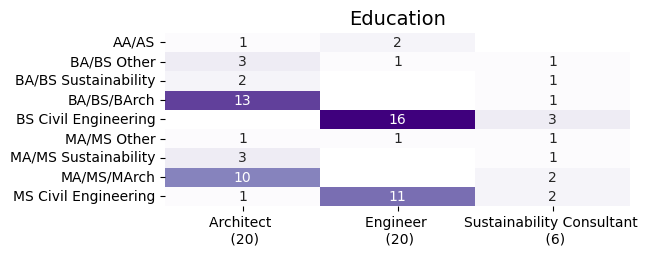

In [4]:
# education
col = 'Education'

# initialize dataframe
degrees = list(set(dct_education.values()))
degrees.sort()
dft = pd.DataFrame(data=0, index=degrees, columns=['Architect', 'Engineer', 'Sustainability Consultant'])

# fill in dataframe
for cat in dft.columns:
    for degs in df_demog.loc[df_demog['Arch/Eng'] == cat][col].values:
        for deg in degs.split(', '):
            deg = dct_education[deg]
            dft.loc[deg, cat] += 1
        
# plot
fig, ax = plt.subplots(figsize=(6,len(dft)/4))
sns.heatmap(dft.replace({0:np.nan}), cmap='Purples', annot=True, ax=ax, cbar=False)
xticklabels = []
for label in ax.get_xticklabels():
    label = label.get_text()
    n = df_demog['Arch/Eng'].value_counts()[label]
    label = f'{label} \n ({n})'
    xticklabels.append(label)
ax.set_xticklabels(xticklabels);
ax.set_title(col, fontsize=14)

plt.savefig('outputs/figures/Demographics_Education.png', bbox_inches='tight', dpi=dpi)

In [5]:
# sustainability certification
cat = 'Sustainability Certifications'
sust_certs = []
for val in df_demog[cat].values:
    sust_certs += val.split(', ')
sust_certs = list(set(sust_certs))
sust_certs.sort()
sust_certs

['ASHRAE BEMP',
 'ActiveScore AP',
 'CPHC',
 'CPHD',
 'Construction Life-Cycle Assessment Specialist',
 'ENV SP',
 'EcoDistricts AP',
 'Fitwel Ambassador',
 'LEED AP',
 'LEED AP BD+C',
 'LEED AP ID+C',
 'LEED Fellow',
 'LEED GA',
 'LFA',
 'NFRC Certified Simulator',
 'None',
 'SITES AP',
 'WELL AP']

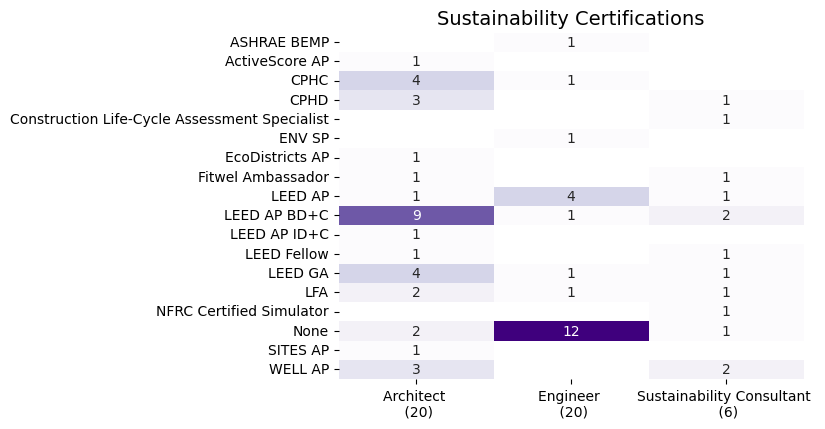

In [6]:
# education
col = 'Sustainability Certifications'

# initialize dataframe
dft = pd.DataFrame(data=0, index=sust_certs, columns=['Architect', 'Engineer', 'Sustainability Consultant'])

# fill in dataframe
for cat in dft.columns:
    for degs in df_demog.loc[df_demog['Arch/Eng'] == cat][col].values:
        for deg in degs.split(', '):
            dft.loc[deg, cat] += 1
        
# plot
fig, ax = plt.subplots(figsize=(6,len(dft)/4))
sns.heatmap(dft.replace({0:np.nan}), cmap='Purples', annot=True, ax=ax, cbar=False)
xticklabels = []
for label in ax.get_xticklabels():
    label = label.get_text()
    n = df_demog['Arch/Eng'].value_counts()[label]
    label = f'{label} \n ({n})'
    xticklabels.append(label)
ax.set_xticklabels(xticklabels);
ax.set_title(col, fontsize=14)

plt.savefig('outputs/figures/Demographics_SustCerts.png', bbox_inches='tight', dpi=dpi)


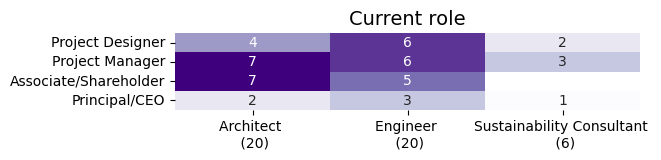

In [7]:
# current role
col = 'Current role'

# initialize dataframe
roles = [
    'Project Designer',
    'Project Manager',
    'Associate/Shareholder',
    'Principal/CEO',
]
dft = pd.DataFrame(data=0, index=roles, columns=['Architect', 'Engineer', 'Sustainability Consultant'])

# fill in dataframe
for cat in dft.columns:
    for degs in df_demog.loc[df_demog['Arch/Eng'] == cat][col].values:
        for deg in degs.split(', '):
            dft.loc[deg, cat] += 1
        
# plot
fig, ax = plt.subplots(figsize=(6,len(dft)/4))
sns.heatmap(dft.replace({0:np.nan}), cmap='Purples', annot=True, ax=ax, cbar=False)
xticklabels = []
for label in ax.get_xticklabels():
    label = label.get_text()
    n = df_demog['Arch/Eng'].value_counts()[label]
    label = f'{label} \n ({n})'
    xticklabels.append(label)
ax.set_xticklabels(xticklabels);
ax.set_title(col, fontsize=14)

plt.savefig('outputs/figures/Demographics_CurrentRole.png', bbox_inches='tight', dpi=dpi)


In [8]:
# sustainability certification
cat = 'Licensure'
licenses = []
for val in df_demog[cat].dropna().values:
    licenses += val.split(', ')
licenses = list(set(licenses))
licenses.sort()
licenses

['AIA', 'Assoc. AIA', 'NCARB', 'PE', 'RA', 'SE']

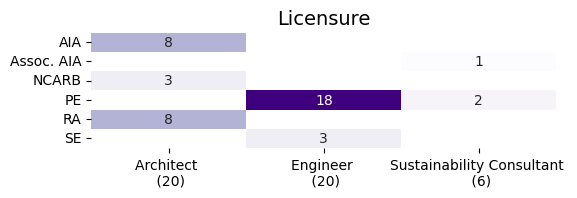

In [9]:
# Licensure

# education
col = 'Licensure'

# initialize dataframe
dft = pd.DataFrame(data=0, index=licenses, columns=['Architect', 'Engineer', 'Sustainability Consultant'])

# fill in dataframe
for cat in dft.columns:
    for degs in df_demog.loc[df_demog['Arch/Eng'] == cat][col].dropna().values:
        for deg in degs.split(', '):
            dft.loc[deg, cat] += 1
        
# plot
fig, ax = plt.subplots(figsize=(6,len(dft)/4))
sns.heatmap(dft.replace({0:np.nan}), cmap='Purples', annot=True, ax=ax, cbar=False)
xticklabels = []
for label in ax.get_xticklabels():
    label = label.get_text()
    n = df_demog['Arch/Eng'].value_counts()[label]
    label = f'{label} \n ({n})'
    xticklabels.append(label)
ax.set_xticklabels(xticklabels);
ax.set_title(col, fontsize=14)

plt.savefig('outputs/figures/Demographics_Licensure.png', bbox_inches='tight', dpi=dpi)


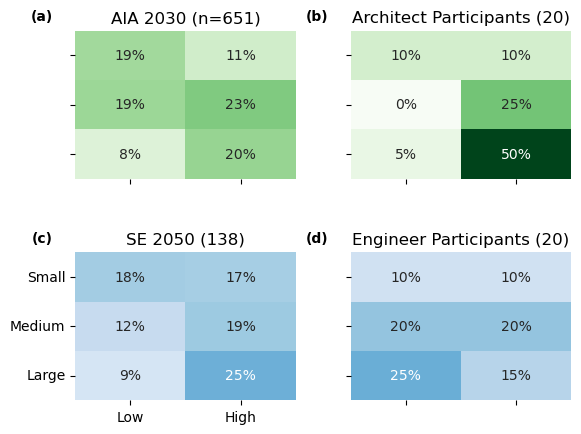

In [10]:
# firm size and involvement relative to SE 2050 and AIA 2030
col1 = 'Firm Size'
col2 = 'Involvement'
cmap = 'Blues'

fig, axes = plt.subplots(2,2, gridspec_kw=dict(hspace=0.5, wspace=0.25))



# architecture, population
ax = axes[0,0]
archeng = 'Architect'
dft_popu = pd.DataFrame(data=0, index=['Small', 'Medium', 'Large'], columns=['Low', 'High'])
for item in df_aia2030['Group'].str.split('/'):
    size, inv = item
    dft_popu.loc[size, inv] += 1
dft_popu = dft_popu/dft_popu.sum().sum()
sns.heatmap(dft_popu, cmap='Greens', annot=True, ax=ax, cbar=False, fmt='.0%', vmin=0, vmax=0.5)
ax.set_title(f"AIA 2030 (n={len(df_aia2030)})")
ax.text(-0.1,1.05,'(a)', ha='right', va='bottom', transform=ax.transAxes, weight='bold')


# architecture, sample
ax = axes[0,1]
dft_samp = pd.DataFrame(data=0, index=['Small', 'Medium', 'Large'], columns=['Low', 'High'])
for item in df_demog.loc[df_demog['Arch/Eng'] == archeng]['Group'].str.split('/'):
    size, inv = item
    dft_samp.loc[size, inv] += 1
dft_samp = dft_samp/dft_samp.sum().sum()
sns.heatmap(dft_samp, cmap='Greens', annot=True, ax=ax, cbar=False, fmt='.0%', vmin=0, vmax=0.5)
ax.set_title(f"{archeng} Participants ({df_demog['Arch/Eng'].value_counts()['Architect']})")
ax.text(-0.1,1.05,'(b)', ha='right', va='bottom', transform=ax.transAxes, weight='bold')


# engineer, population
ax = axes[1,0]
archeng = 'Engineer'
dft_popu = pd.DataFrame(data=0, index=['Small', 'Medium', 'Large'], columns=['Low', 'High'])
for item in df_se2050['Group'].str.split('/'):
    size, inv = item
    dft_popu.loc[size, inv] += 1
dft_popu = dft_popu/dft_popu.sum().sum()
sns.heatmap(dft_popu, cmap='Blues', annot=True, ax=ax, cbar=False, fmt='.0%', vmin=0, vmax=0.5)
ax.set_title(f"SE 2050 ({len(df_se2050)})")
ax.text(-0.1,1.05,'(c)', ha='right', va='bottom', transform=ax.transAxes, weight='bold')


# engineer, sample
ax = axes[1,1]
dft_samp = pd.DataFrame(data=0, index=['Small', 'Medium', 'Large'], columns=['Low', 'High'])
for item in df_demog.loc[df_demog['Arch/Eng'] == archeng]['Group'].str.split('/'):
    size, inv = item
    dft_samp.loc[size, inv] += 1
dft_samp = dft_samp/dft_samp.sum().sum()
sns.heatmap(dft_samp, cmap='Blues', annot=True, ax=ax, cbar=False, fmt='.0%', vmin=0, vmax=0.5)
ax.set_title(f"{archeng} Participants ({df_demog['Arch/Eng'].value_counts()['Engineer']})")
ax.text(-0.1,1.05,'(d)', ha='right', va='bottom', transform=ax.transAxes, weight='bold')


# format
for row, col in product(range(2), range(2)):
    ax = axes[row, col]
    if (row, col) == (1,0):
        ax.tick_params('y', rotation=0)
    else:
        ax.set_xticklabels([])
        ax.set_yticklabels([])
    
plt.savefig('outputs/figures/Participants_vs_CommitmentPrograms.png', bbox_inches='tight', dpi=dpi)

## tags

In [11]:
# most common tags
col = 'TAG2'

srs = df_tags[col].value_counts()
pd.Series(srs.index.values, index=srs).to_excel('outputs/tables/tagcounts.xlsx')

In [12]:
# identify each question with multiple answers
col = 'TAG2'

df_tags['(_lim'] = df_tags[col].str.find('(')

for row in df_tags.index:
    tag2 = df_tags.loc[row][col]
    lim = df_tags.loc[row]['(_lim']
    if lim != -1:
        df_tags.loc[row, f'{col}_cat'] = tag2[:lim-1]
    else:
        df_tags.loc[row, f'{col}_cat'] = np.nan

srs = df_tags['TAG2_cat'].value_counts()


In [13]:
col = 'TAG2_cat'
cats = list(df_tags[col].value_counts().index)
cats.sort()
cats

['ADVANCED LCA: A barrier to adopting advanced LCA methods may be',
 'ADVANCED LCA: Advanced LCA is better because it',
 'ADVANCED LCA: For widespread use, advanced LCA methods must',
 'ADVANCED LCA: Whether I use advanced LCA methods depends on',
 "APPLICATION: Our firm's LCA practice is",
 'APPLICATION: Reduction strategies include',
 'APPLICATION: The LCA workload is shared with other firms',
 'APPLICATION: We aspire to',
 'APPLICATION: We follow external guidelines',
 'APPLICATION: We have worked with a sustainability consultant on the LCA',
 'BIOGENIC CARBON: For biogenic carbon in my LCAs, I',
 'BIOGENIC CARBON: How I deal with biogenic carbon depends on',
 'DATA: For embodied carbon data, we use',
 'DATA: Material quantity takeoffs come from',
 'DATA: We request EPDs on our projects',
 'DLCA: A barrier to adopting DLCA may be',
 'DLCA: Compared to traditional LCA, DLCA is better',
 'DLCA: For widespread use, DLCA must',
 'DLCA: Whether I use DLCA depends on',
 'LEARNING: A resou

In [14]:
col = 'TAG2_cat'
cat = 'DATA: For embodied carbon data, we use'
df_tags.loc[df_tags[col] == cat]['TAG2'].value_counts()

TAG2
DATA: For embodied carbon data, we use (EPDs)                                                16
DATA: For embodied carbon data, we use (EPDs from EC3)                                       14
DATA: For embodied carbon data, we use (average EPDs)                                         8
DATA: For embodied carbon data, we use (EPDs from material suppliers)                         4
DATA: For embodied carbon data, we use (LCA tool)                                             3
DATA: For embodied carbon data, we use (EPDs), NOT                                            2
DATA: For embodied carbon data, we use (EPDs from NRMCA)                                      1
DATA: For embodied carbon data, we use (EPDs from Sustainable Minds Transparency Catalog)     1
DATA: For embodied carbon data, we use (primary data)                                         1
Name: count, dtype: int64

/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


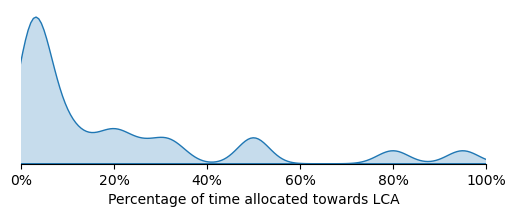

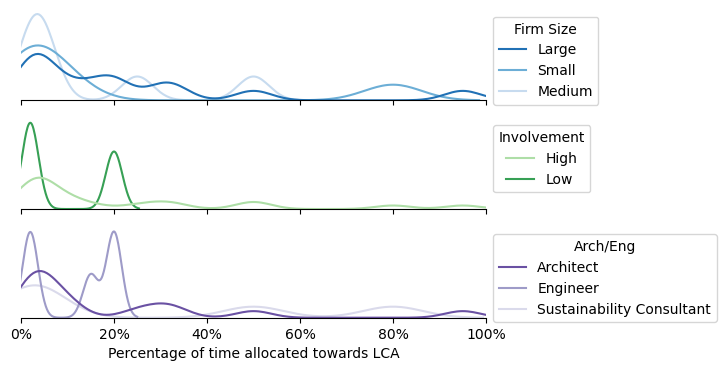

In [15]:
# TIME: The time I allocate towards LCA work is (25%)

col = 'TAG2'
cat = 'TIME: The time I allocate towards LCA work is'
dft = df_tags.loc[df_tags[col].str.startswith(cat)]
# dft[col].str[len(cat):]
srs = dft[col].str.find('%')
dft = dft.loc[srs.loc[srs>0].index]

label = 'Percentage of time allocated towards LCA'
dft[label] = dft[col].str[len(cat)+2:-2].astype(float)/100

fig, ax = plt.subplots(figsize=(6,2))
# sns.stripplot(dft[label], ax=ax, orient='h')
ax.set_xlim(0,1)
sns.kdeplot(dft[label], ax=ax, fill=True, bw_adjust=0.25)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

plt.savefig('outputs/figures/TimeTowardsLCA.png', bbox_inches='tight', dpi=dpi)

# add other features
fig, axes = plt.subplots(3,1, figsize=(6,4), sharex=True)

for i, (y, palette) in enumerate(zip(['Firm Size', 'Involvement', 'Arch/Eng'], ['Blues_r', 'Greens', 'Purples_r'])):
    ax = axes[i]
    dct = dict(df_demog.set_index('ID')[y])
    dft[y] = dft['ID'].map(dct)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        # sns.stripplot(data=dft, x=label, y=y, orient='h', ax=ax)
        sns.kdeplot(data=dft, x=label, hue=y, ax=ax, bw_adjust=0.25, legend=True, palette=palette, common_norm=False)
        ax.set_xlim(0,1)
        sns.move_legend(ax, bbox_to_anchor=(1,1), loc='upper left')
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

plt.savefig('outputs/figures/TimeTowardsLCA_split.png', bbox_inches='tight', dpi=dpi)


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


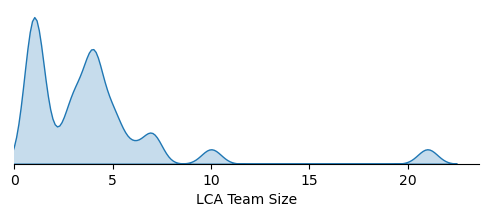

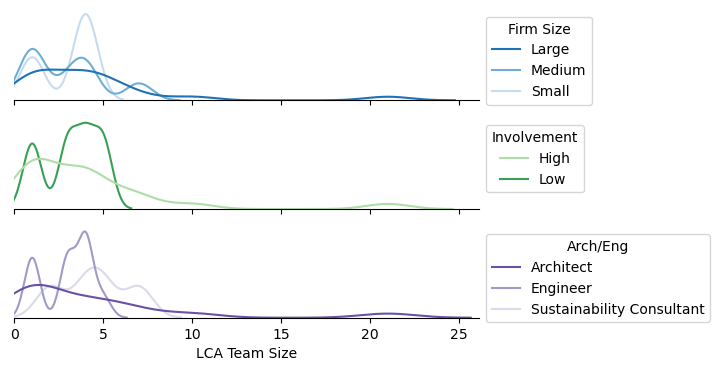

In [16]:
# TEAM: The LCA team is comprised of (1 person)
col = 'TAG2'
cat = 'TEAM: The LCA team is comprised of'
dft = df_tags.loc[df_tags[col].str.startswith(cat)]
srs = dft[col].str[len(cat)+2:]
terms = []
ind2keep = []
for ind, term, loc in zip(srs.index, srs.values, srs.str.find(' ')):
    try:
        terms.append(int(term[:loc]))
        ind2keep.append(ind)
    except:
        pass

dft = dft.loc[ind2keep]
label = 'LCA Team Size'
dft[label] = terms

fig, ax = plt.subplots(figsize=(6,2))
# sns.stripplot(dft[label], ax=ax, orient='h')
sns.kdeplot(dft[label], ax=ax, fill=True, bw_adjust=0.25)
ax.set_xlim(0,)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)

plt.savefig('outputs/figures/LCATeamSize.png', bbox_inches='tight', dpi=dpi)


# add other features
fig, axes = plt.subplots(3,1, figsize=(6,4), sharex=True)

for i, (y, palette) in enumerate(zip(['Firm Size', 'Involvement', 'Arch/Eng'], ['Blues_r', 'Greens', 'Purples_r'])):
    ax = axes[i]
    dct = dict(df_demog.set_index('ID')[y])
    dft[y] = dft['ID'].map(dct)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        # sns.stripplot(data=dft, x=label, y=y, orient='h', ax=ax)
        sns.kdeplot(data=dft, x=label, hue=y, ax=ax, bw_adjust=0.5, legend=True, palette=palette, common_norm=False)
        ax.set_xlim(0,)
        sns.move_legend(ax, bbox_to_anchor=(1,1), loc='upper left')
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.get_yaxis().set_visible(False)

plt.savefig('outputs/figures/LCATeamSize_split.png', bbox_inches='tight', dpi=dpi)


/Users/martintorres/mambaforge/envs/waterweed/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


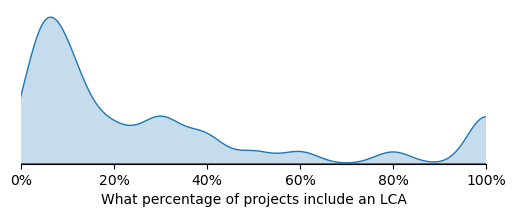

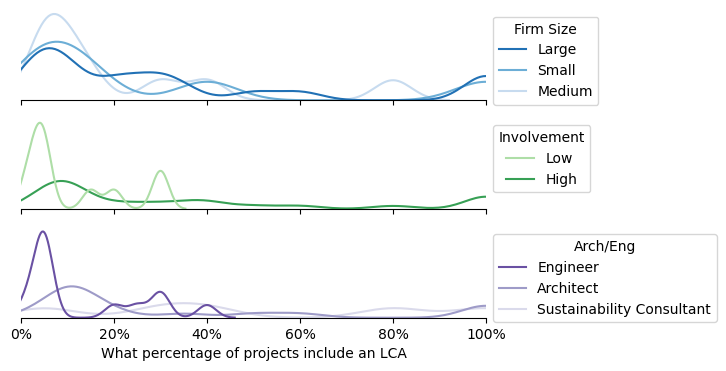

In [17]:
# PROJECTS: Our firm performs LCAs on (10% of projects)

col = 'TAG2'
cat = 'PROJECTS: Our firm performs LCAs on'
dft = df_tags.loc[df_tags[col].str.startswith(cat)]
srs = dft[col].str[len(cat):]
srs = srs.str.find('%')
dft = dft.loc[srs.loc[srs>0].index]
terms = []
for string in dft[col]:
    if string.find('-') > -1:
        string = string[string.find('-'):]
    term = ''.join(c for c in string if c.isdigit())
    terms.append(float(term)/100)

label = 'What percentage of projects include an LCA'
dft[label] = terms

fig, ax = plt.subplots(figsize=(6,2))
# sns.stripplot(dft[label], ax=ax, orient='h')
sns.kdeplot(dft[label], ax=ax, fill=True, bw_adjust=0.25)
ax.set_xlim(0,1)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.get_yaxis().set_visible(False)
ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

plt.savefig('outputs/figures/LCAProjectPercentage.png', bbox_inches='tight', dpi=dpi)


# add other features
fig, axes = plt.subplots(3,1, figsize=(6,4), sharex=True)

for i, (y, palette) in enumerate(zip(['Firm Size', 'Involvement', 'Arch/Eng'], ['Blues_r', 'Greens', 'Purples_r'])):
    ax = axes[i]
    dct = dict(df_demog.set_index('ID')[y])
    dft[y] = dft['ID'].map(dct)
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        # sns.stripplot(data=dft, x=label, y=y, orient='h', ax=ax)
        sns.kdeplot(data=dft, x=label, hue=y, ax=ax, bw_adjust=0.25, legend=True, palette=palette, common_norm=False)
        ax.set_xlim(0,1)
        sns.move_legend(ax, bbox_to_anchor=(1,1), loc='upper left')
        ax.spines[['top', 'right', 'left']].set_visible(False)
        ax.get_yaxis().set_visible(False)
        ax.xaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(1.0))

plt.savefig('outputs/figures/LCAProjectPercentage_split.png', bbox_inches='tight', dpi=dpi)


/var/folders/_q/2m7sk55j2hd11pdxzfgjpwz80000gn/T/ipykernel_42127/200570655.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(yticklabels)


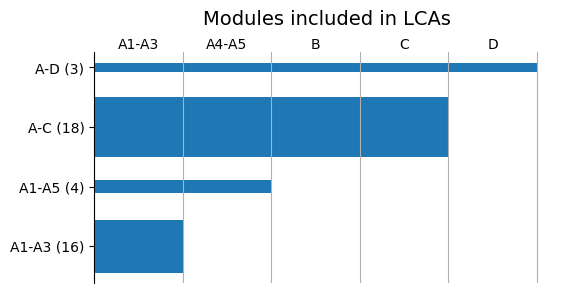

In [18]:
#SCOPE: Our LCAs include modules (A1-A3)
col = 'TAG2'
cat = 'SCOPE: Our LCAs include modules'
dft = df_tags.loc[df_tags[col].str.startswith(cat)]
dft = dft[col].str[len(cat)+2:-1].value_counts()

dict_length = {
    'A1-A3': 1,
    'A1-A5': 2,
    'A-C': 4,
    'A-D': 5,
}

dft = dft.loc[dict_length.keys()]

#data
x = dft.index
h = [dict_length[ele] for ele in dft.index]
w = dft.values/np.max(dft.values)

#bar plot
fig, ax = plt.subplots(figsize=(6,3))
ax.barh(x, height = w, width = h)
ax.grid(which='major', axis='x')

ymin, ymax = ax.get_ylim()
for x, module in enumerate(['A1-A3', 'A4-A5', 'B', 'C', 'D']):
    ax.text(x+0.5, ymax, module, ha='center', va='bottom')

ax.set_xticklabels([])
ax.tick_params(colors='white', which='major', axis='x')
yticklabels = []
for y in ax.get_yticklabels():
    yticklabels.append(f'{y.get_text()} ({dft[y.get_text()]})')
ax.set_yticklabels(yticklabels)
ax.text(x=0.5, y=1.1, s='Modules included in LCAs', ha='center', va='bottom', transform=ax.transAxes, fontsize=14)
ax.spines[['top', 'right', 'bottom']].set_visible(False)

plt.savefig('outputs/figures/LCAModules.png', bbox_inches='tight', dpi=dpi)


In [19]:
# MOTIVATION: Our firm's motivation for LCA is (client demand)

# how many people mention green building cert?
col = 'TAG2'
cat = "MOTIVATION: Our firm's motivation for LCA is (GBC"
n = len(df_tags.loc[df_tags[col].str.startswith(cat)]['ID'].unique())
print(f'{n} people mention green building certifications')
print('')

# how many people mention policy?
col = 'TAG2'
cat = "MOTIVATION: Our firm's motivation for LCA is (Policy"
n = len(df_tags.loc[df_tags[col].str.startswith(cat)]['ID'].unique())
print(f'{n} people mention policy')
print('')


# how many people mention commitment programs?
col = 'TAG2'
cat = "MOTIVATION: Our firm's motivation for LCA is (CP"
n = len(df_tags.loc[df_tags[col].str.startswith(cat)]['ID'].unique())
print(f'{n} people mention commitment programs')
print('')


34 people mention green building certifications

26 people mention policy

32 people mention commitment programs



/var/folders/_q/2m7sk55j2hd11pdxzfgjpwz80000gn/T/ipykernel_42127/2626409088.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dft[split] = dft['ID'].map(dct)


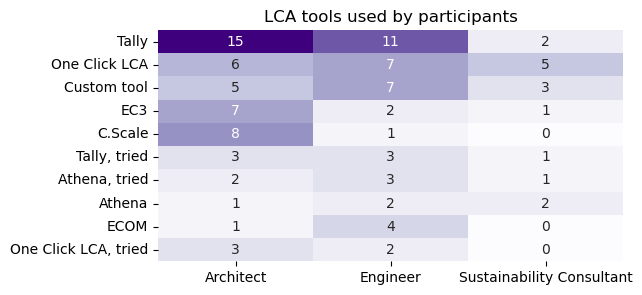

In [20]:
# architects vs engineers LCA tools used
col = 'TAG2'
cat = 'TOOL: To perform LCA, our firm uses'

# prepare dataframe
dft = df_tags.loc[df_tags[col].str.startswith(cat)]

# add in arch/eng split
split = 'Arch/Eng'
dct = dict(df_demog.set_index('ID')[split])
dft[split] = dft['ID'].map(dct)
srs = dft[col].str[len(cat):]

# get a list of all tools
tools = list(dft[col].str[len(cat)+2:-1].unique())
tools.sort()

# add value counts ot plot
dft_plot = pd.DataFrame(index=tools, columns=['Architect', 'Engineer', 'Sustainability Consultant'])
for archeng in dft[split].unique():
    srs = dft.loc[dft[split] == archeng][col].str[len(cat)+2:-1]
    dft_plot[archeng] = srs.value_counts()

dft_plot = dft_plot.fillna(0.)
dft_plot['Total'] = dft_plot.sum(axis=1)
dft_plot = dft_plot.sort_values('Total', ascending=False)
# plot
fig, ax = plt.subplots(figsize=(6,3))
sns.heatmap(dft_plot.iloc[:10,:-1], cmap='Purples', annot=True, cbar=False, ax=ax)
ax.set_title('LCA tools used by participants')

plt.savefig('outputs/figures/Demographics_LCATool.png', bbox_inches='tight', dpi=dpi)


# High level takeaways

## institutional support is critical

In [21]:
# institutional support is critical
col = 'TAG2_cat'
tag2_cat = 'LEARNING: A resource I use for learning LCA is'
df_tags.loc[df_tags[col] == tag2_cat]['TAG2'].str[len(tag2_cat):].value_counts()

TAG2
(on the job)                                27
(CLF)                                       17
(In-House Resources)                        14
(SE 2050)                                   13
(university)                                11
(peer network)                               6
(Tally)                                      5
(online search)                              4
(software tutorials)                         3
(SEI Prestandard)                            3
(One Click LCA)                              3
(AIA)                                        2
(IStructE)                                   2
(USGBC)                                      2
(LCA tool customer support)                  2
(LEED)                                       2
(Athena)                                     2
(EPDs)                                       2
(ISO Standards)                              1
(SE 2050 ECAPs)                              1
(webinars)                                   1
(US LCI)

In [22]:
# institutional support is critical
col = 'TAG2_cat'
tag2_cat = "MOTIVATION: Our firm's motivation for LCA is"
srs = df_tags.loc[df_tags[col] == tag2_cat]['TAG2'].str[len(tag2_cat):].value_counts()
srs.loc[srs.index.str.startswith(' (GBC')]

TAG2
(GBC - LEED)            26
(GBC)                   10
(GBC - WELL)             4
(GBC - ILFI/ZCC)         4
(GBC - ILFI/LBC)         3
(GBC, NO)                2
(GBC - UN Compact)       1
(GBC - LEED, NO)         1
(GBC - ILFI)             1
(GBC - Envision)         1
(GBC - Active Score)     1
(GBC - Green Globes)     1
Name: count, dtype: int64

In [23]:
df_tags.loc[df_tags['CATEGORY']=='PROBLEM']['TAG2'].value_counts()

TAG2
PROBLEM: A problem with LCAs is (data inaccuracy)                                                     43
PROBLEM: A problem with LCAs is (reliability of results)                                              27
PROBLEM: It is difficult to (navigate BIM)                                                            26
PROBLEM: A problem with LCAs is (lack of standardization)                                             24
PROBLEM: It is difficult to (define an EC benchmark)                                                  19
PROBLEM: A problem with LCAs is (LCAs are under valued)                                               16
PROBLEM: It is difficult to (quantify materials)                                                      14
PROBLEM: A problem with LCAs is (results are not interpretable)                                       14
PROBLEM: QUOTE                                                                                        14
PROBLEM: A problem with LCAs is (cumbersome proces

In [24]:
# institutional support is critical
col = 'TAG2_cat'
tag2_cat = 'PROBLEM: It is difficult to'
df_tags.loc[df_tags[col] == tag2_cat]['TAG2'].str[len(tag2_cat):].value_counts()

TAG2
(navigate BIM)                                           26
(define an EC benchmark)                                 19
(quantify materials)                                     18
(train others to do LCA)                                 14
(prioritize LCA over other work)                         11
(coordinate the design team)                              8
(communicate results to client)                           5
(balance EC with other impact categories)                 4
(model existing buildings)                                4
(define the scope of the LCA)                             4
(incorporate LCAs in design workflow)                     2
(obtain EPDs)                                             2
(select an LCA tool)                                      2
(standardize LCA)                                         2
(align with standards)                                    2
(ensure LCAs are comparable)                              1
(develop a custom LCA tool)        

## BIM modeling and quantity takeoffs are a major point of friction

In [25]:
# BIM modeling and quantity takeoffs are major points of friction
tag2_cat = 'DATA: Material quantity takeoffs come from'

srs = df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].str[len(tag2_cat):]#.value_counts()
srs.value_counts()
ind_revit = srs.loc[srs == ' (Revit)'].index
ind_assem = srs.loc[srs == ' (assembly factors)'].index

for ID in df_tags.loc[ind_assem]['ID'].unique():
    if ID not in df_tags.loc[ind_revit]['ID'].unique():
        print(ID)

In [26]:
# where do people get data?
col = 'TAG2_cat'
tag2_cat = "DATA: Material quantity takeoffs come from"
print(df_tags.loc[df_tags[col] == tag2_cat]['TAG2'].str[len(tag2_cat):].value_counts())

TAG2
(Revit)                     39
(assembly factors)          14
(structural engineer)       10
(drawings)                   8
(contractor)                 5
(hand calculations)          2
(material suppliers)         2
(Ace Lab)                    1
(AI)                         1
(Autodesk AI - Takeoff)      1
(construction estimates)     1
(cost estimator)             1
(GC)                         1
(Rhino)                      1
Name: count, dtype: int64


In [27]:
# where do people get data?
col = 'TAG2_cat'
tag2_cat = "DATA: For embodied carbon data, we use"
print(df_tags.loc[df_tags[col] == tag2_cat]['TAG2'].str[len(tag2_cat):].value_counts())

TAG2
(EPDs)                                                16
(EPDs from EC3)                                       14
(average EPDs)                                         8
(EPDs from material suppliers)                         4
(LCA tool)                                             3
(EPDs), NOT                                            2
(EPDs from NRMCA)                                      1
(EPDs from Sustainable Minds Transparency Catalog)     1
(primary data)                                         1
Name: count, dtype: int64


## WBLCA practitioners are unsatisfied with data quality

In [28]:
# wbLCA practitioners are unsatisfied with data quality

tag2_cat = 'PROBLEM: A problem with LCAs is'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
PROBLEM: A problem with LCAs is (data inaccuracy)                                                     43
PROBLEM: A problem with LCAs is (reliability of results)                                              28
PROBLEM: A problem with LCAs is (lack of standardization)                                             24
PROBLEM: A problem with LCAs is (LCAs are under valued)                                               16
PROBLEM: A problem with LCAs is (results are not interpretable)                                       14
PROBLEM: A problem with LCAs is (how much time they take, NOT)                                        13
PROBLEM: A problem with LCAs is (cost)                                                                12
PROBLEM: A problem with LCAs is (cumbersome process)                                                  12
PROBLEM: A problem with LCAs is (LCA tools are insufficient)                                          12
PROBLEM: A problem with LCAs is (how much time the

In [29]:
lst = list(df_tags['TAG2_cat'].unique())
[ele for ele in lst if str(ele).find('bio') != -1]

['BIOGENIC CARBON: For biogenic carbon in my LCAs, I',
 'BIOGENIC CARBON: How I deal with biogenic carbon depends on']

In [30]:
lst = list(df_tags['TAG2_cat'].unique())
[ele for ele in lst if str(ele).find('bio') != -1]

# what do people do about biogenic carbon?
tag2_cat = 'BIOGENIC CARBON: For biogenic carbon in my LCAs, I'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
BIOGENIC CARBON: For biogenic carbon in my LCAs, I (exclude it)                   18
BIOGENIC CARBON: For biogenic carbon in my LCAs, I (report it separately)         16
BIOGENIC CARBON: For biogenic carbon in my LCAs, I (defer to the LCA software)     2
BIOGENIC CARBON: For biogenic carbon in my LCAs, I (include it)                    1
Name: count, dtype: int64

In [31]:
# what does biogenic carbon depend on

tag2_cat = 'BIOGENIC CARBON: How I deal with biogenic carbon depends on'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
BIOGENIC CARBON: How I deal with biogenic carbon depends on (the client)           2
BIOGENIC CARBON: How I deal with biogenic carbon depends on (FSC certification)    1
Name: count, dtype: int64

## WBLCA Practitioners are amenable to advanced LCA with some caveats

In [32]:
# wbLCA practitioners are amenable to advanced LCA methods with some caveats
inds = []
for tag in ['PLCA', 'DLCA', 'ADVANCED LCA']:
    srs = df_tags['TAG2'].str.startswith(tag)
    inds += list(srs.loc[srs==True].index)
inds = list(set(inds))
inds.sort()

df_tags.loc[inds]['TAG2'].value_counts()[:20]

TAG2
ADVANCED LCA: I am interested to learn more about advanced LCA methods                             44
PLCA: I have heard of PLCA, NOT                                                                    31
PLCA: PLCA seems like a good idea                                                                  30
DLCA: I am interested to learn more about DLCA                                                     27
PLCA: I could incorporate PLCA in my practice                                                      23
DLCA: I have heard of DLCA, NOT                                                                    23
DLCA: I could incorporate DLCA in my practice                                                      20
PLCA: Compared to traditional LCA, PLCA is better for (transparency)                               16
DLCA: Compared to traditional LCA, DLCA is better (accuracy)                                       13
PLCA: I am interested to learn more about PLCA                               

In [33]:
df_tags.loc[inds]['TAG2'].value_counts()[[ele for ele in df_tags['TAG2'].value_counts().index if ele.find('I have heard of') != -1]]

TAG2
PLCA: I have heard of PLCA, NOT    31
DLCA: I have heard of DLCA, NOT    23
DLCA: I have heard of DLCA          8
PLCA: I have heard of PLCA          2
Name: count, dtype: int64

In [34]:
tag1 = 'PLCA: I could incorporate PLCA in my practice'
tag2 = 'DLCA: I could incorporate DLCA in my practice'

print('PLCA: ',len(df_tags.loc[df_tags['TAG2'] == tag1]['ID'].unique()))
print('DLCA: ',len(df_tags.loc[df_tags['TAG2'] == tag2]['ID'].unique()))

PLCA:  23
DLCA:  20


In [35]:
# what does advanced LCA depend on

tag2_cat = 'ADVANCED LCA: Whether I use advanced LCA methods depends on'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
ADVANCED LCA: Whether I use advanced LCA methods depends on (how difficult it is)                 13
ADVANCED LCA: Whether I use advanced LCA methods depends on (client demand)                        6
ADVANCED LCA: Whether I use advanced LCA methods depends on (if other firms are using it)          4
ADVANCED LCA: Whether I use advanced LCA methods depends on (how much it impacts project work)     3
ADVANCED LCA: Whether I use advanced LCA methods depends on (how much it costs)                    2
Name: count, dtype: int64

In [36]:
# what does advanced LCA depend on

tag2_cat = 'ADVANCED LCA: For widespread use, advanced LCA methods must'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
ADVANCED LCA: For widespread use, advanced LCA methods must (be available in LCA software)         7
ADVANCED LCA: For widespread use, advanced LCA methods must (be included in education)             2
ADVANCED LCA: For widespread use, advanced LCA methods must (have transparent methods and data)    1
Name: count, dtype: int64

In [37]:
# how do people feel about pLCA
df_tags.loc[df_tags['CATEGORY'] == 'PLCA']['TAG2'].value_counts()


tag2_cat = 'PLCA: Compared to traditional LCA, PLCA is better for'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
PLCA: Compared to traditional LCA, PLCA is better for (transparency)             16
PLCA: Compared to traditional LCA, PLCA is better for (early design)             10
PLCA: Compared to traditional LCA, PLCA is better for (accuracy)                  7
PLCA: Compared to traditional LCA, PLCA is better for (benchmarking)              6
PLCA: Compared to traditional LCA, PLCA is better for (EC reduction)              4
PLCA: Compared to traditional LCA, PLCA is better for (product selection)         4
PLCA: Compared to traditional LCA, PLCA is better for (realistic)                 4
PLCA: Compared to traditional LCA, PLCA is better for (business)                  2
PLCA: Compared to traditional LCA, PLCA is better for (data transparency)         2
PLCA: Compared to traditional LCA, PLCA is better for (approachability)           1
PLCA: Compared to traditional LCA, PLCA is better for (confidence in results)     1
PLCA: Compared to traditional LCA, PLCA is better for (data accessibili

In [38]:
# barriers for pLCA

tag2_cat = 'PLCA: A barrier to adopting PLCA may be'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
PLCA: A barrier to adopting PLCA may be (difficulty communicating results)    6
PLCA: A barrier to adopting PLCA may be (reliance on assumptions)             4
PLCA: A barrier to adopting PLCA may be (complexity)                          3
PLCA: A barrier to adopting PLCA may be (limited data)                        1
Name: count, dtype: int64

In [39]:
# how do people feel about dLCA
df_tags.loc[df_tags['CATEGORY'] == 'DLCA']['TAG2'].value_counts()


tag2_cat = 'DLCA: Compared to traditional LCA, DLCA is better'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
DLCA: Compared to traditional LCA, DLCA is better (accuracy)                    13
DLCA: Compared to traditional LCA, DLCA is better (whole-life carbon)            7
DLCA: Compared to traditional LCA, DLCA is better (time-dependent emissions)     5
DLCA: Compared to traditional LCA, DLCA is better (biogenic carbon)              4
DLCA: Compared to traditional LCA, DLCA is better (biogenic materials)           3
DLCA: Compared to traditional LCA, DLCA is better (different GHGs)               2
DLCA: Compared to traditional LCA, DLCA is better (research)                     2
DLCA: Compared to traditional LCA, DLCA is better (storytelling)                 2
DLCA: Compared to traditional LCA, DLCA is better (assembly comparisons)         1
DLCA: Compared to traditional LCA, DLCA is better (material reuse)               1
DLCA: Compared to traditional LCA, DLCA is better (Module B)                     1
DLCA: Compared to traditional LCA, DLCA is better (offsetting)                   1

In [40]:
# barriers for dLCA

tag2_cat = 'DLCA: A barrier to adopting DLCA may be'
df_tags.loc[df_tags['TAG2_cat'] == tag2_cat]['TAG2'].value_counts()

TAG2
DLCA: A barrier to adopting DLCA may be (complexity)                          12
DLCA: A barrier to adopting DLCA may be (reliance on assumptions)              9
DLCA: A barrier to adopting DLCA may be (difficulty communicating results)     5
DLCA: A barrier to adopting DLCA may be (learning curve)                       3
Name: count, dtype: int64

# Summary tables

In [41]:
threshold = 0.20
col = 'CATEGORY'

rows = []
for cat in df_tags[col].unique():
    srs = df_tags.loc[df_tags[col] == cat]['TAG2'].value_counts()
    srs_prop = srs / 46
    mask = srs_prop >= threshold
    if mask.sum() == 0:
        continue
    rows.append({'Tag': cat, 'Count': '', 'Proportion': ''})  # category header row
    for tag in srs[mask].index:
        rows.append({'Tag': tag, 'Count': srs[tag], 'Proportion': srs_prop[tag]})
    rows.append({'Tag': '', 'Count': '', 'Proportion': ''})   # blank separator row

df_export = pd.DataFrame(rows)
df_export.to_excel('outputs/tables/top_comments_by_category.xlsx', index=False)


# Demographic analysis of high-level takeaways

Do professional demographics (discipline, role, firm size, involvement level) differentiate the four high-level takeaways from this study?

In [42]:
# merge demographic columns into df_tags for cross-tabulation
demo_cols = ['Arch/Eng', 'Current role', 'Firm Size', 'Involvement']
df_merged = df_tags.merge(df_demog[['ID'] + demo_cols], on='ID', how='left')

N = len(df_demog)  # total participants (46)

def participant_counts(df, demo_col):
    """Count unique participants per demographic group who appear in df."""
    totals = df_demog.groupby(demo_col)['ID'].nunique()
    counts = df.groupby(demo_col)['ID'].nunique()
    result = pd.DataFrame({'n': counts, 'total': totals}).fillna(0)
    result['n'] = result['n'].astype(int)
    result['pct'] = (result['n'] / result['total'] * 100).round(0).astype(int)
    result['label'] = result['n'].astype(str) + '/' + result['total'].astype(str)
    return result[['n', 'total', 'label']]

## Takeaway 1: Institutions are critical to motivating wbLCA

The takeaway holds universally — every participant cited institutional factors. The key demographic split is in **which institution**: SE 2050 is an engineer-exclusive driver (20/20 engineers), while AIA 2030 skews strongly toward architects (11/20). Policy and LEED motivate both disciplines but more so architects and sustainability consultants. No other demographic variable differentiates this takeaway.

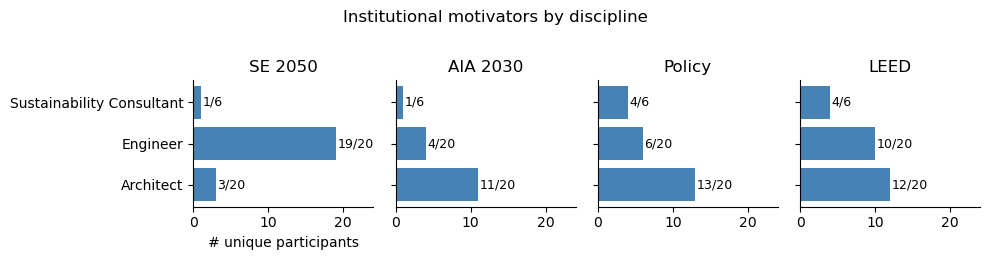

In [43]:
# Institutional motivators by discipline
institutional_tags = {
    'SE 2050':  df_merged['TAG2'].str.contains('CP - SE 2050', na=False),
    'AIA 2030': df_merged['TAG2'].str.contains('CP - AIA 2030', na=False),
    'Policy':   df_merged['TAG2'].str.contains(r'motivation.*\(Policy', na=False, regex=True) &
                ~df_merged['TAG2'].str.contains('NOT', na=False),
    'LEED':     df_merged['TAG2'].str.contains(r'motivation.*GBC - LEED\)', na=False, regex=True) &
                ~df_merged['TAG2'].str.contains('NO', na=False),
}

fig, axes = plt.subplots(1, len(institutional_tags), figsize=(10, 2.5), sharey=True)
for ax, (label, mask) in zip(axes, institutional_tags.items()):
    counts = participant_counts(df_merged[mask], 'Arch/Eng')
    ax.barh(counts.index, counts['n'], color='steelblue')
    for i, (idx, row) in enumerate(counts.iterrows()):
        ax.text(row['n'] + 0.2, i, row['label'], va='center', fontsize=9)
    ax.set_xlim(0, 24)
    ax.set_title(label)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_xlabel('# unique participants')
fig.suptitle("Institutional motivators by discipline", y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_Takeaway1_InstitutionalMotivators.png', bbox_inches='tight', dpi=dpi)

## Takeaway 2: Material quantity takeoffs are a major point of friction

Near-universal (43/46 participants). BIM/Revit issues were cited by 44/46 regardless of discipline, role, firm size, or involvement. The only demographic nuance: architects disproportionately source quantities from the structural engineer, adding a cross-disciplinary coordination dependency that engineers do not face.

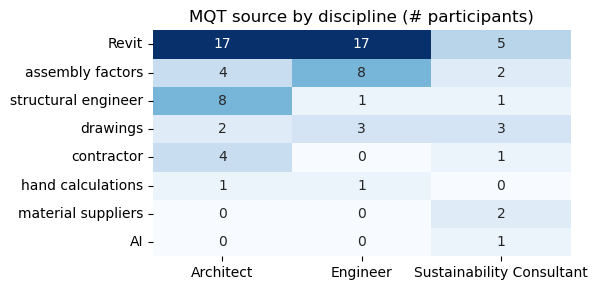

In [44]:
# MQT source by discipline
mqt_cat = 'DATA: Material quantity takeoffs come from'
df_mqt = df_merged[df_merged['TAG2_cat'] == mqt_cat].copy()
df_mqt['source'] = df_mqt['TAG2'].str[len(mqt_cat) + 2:-1]

# pivot: disciplines as columns, sources as rows
pivot = df_mqt.pivot_table(index='source', columns='Arch/Eng', values='ID',
                            aggfunc='nunique', fill_value=0)
pivot['Total'] = pivot.sum(axis=1)
pivot = pivot.sort_values('Total', ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(pivot.drop(columns='Total').iloc[:8], cmap='Blues', annot=True,
            fmt='d', cbar=False, ax=ax)
ax.set_title('MQT source by discipline (# participants)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_Takeaway2_MQTSource.png', bbox_inches='tight', dpi=dpi)

## Takeaway 3: Data quality remains a persistent issue

The most demographically uniform finding in the study. Data inaccuracy was cited by 43/46 participants and reliability concerns by 28/46, with no meaningful differentiation by discipline, role, firm size, or involvement. The one small signal: sustainability consultants proportionally flag results as non-comparable more often (3/6), reflecting their cross-firm exposure.

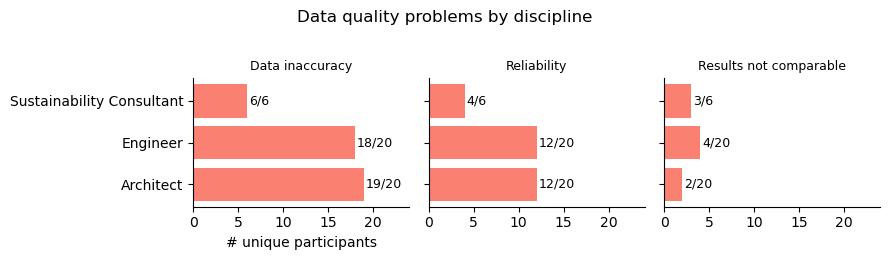

In [45]:
# Data quality problems by discipline
dq_tags = {
    'Data inaccuracy':      df_merged['TAG2'] == 'PROBLEM: A problem with LCAs is (data inaccuracy)',
    'Reliability':          df_merged['TAG2'] == 'PROBLEM: A problem with LCAs is (reliability of results)',
    'Results not comparable': df_merged['TAG2'] == 'PROBLEM: A problem with LCAs is (results are not comparable)',
}

fig, axes = plt.subplots(1, len(dq_tags), figsize=(9, 2.5), sharey=True)
for ax, (label, mask) in zip(axes, dq_tags.items()):
    counts = participant_counts(df_merged[mask], 'Arch/Eng')
    ax.barh(counts.index, counts['n'], color='salmon')
    for i, (idx, row) in enumerate(counts.iterrows()):
        ax.text(row['n'] + 0.2, i, row['label'], va='center', fontsize=9)
    ax.set_xlim(0, 24)
    ax.set_title(label, fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)
axes[0].set_xlabel('# unique participants')
fig.suptitle("Data quality problems by discipline", y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_Takeaway3_DataQuality.png', bbox_inches='tight')

Exclude biogenic C — by discipline:  Arch 9/20 (45%), Eng 9/20 (45%), Sust. Consult. 0/6 (0%)
Unclear assumptions — by discipline: Arch 9/20 (45%), Eng 4/20 (20%), Sust. Consult. 1/6 (17%)
Exclude biogenic C — by involvement: High 10/31 (32%), Low 8/15 (53%)
Exclude biogenic C — by firm size:   Large 7/23 (30%), Medium 5/14 (36%), Small 6/9 (67%)


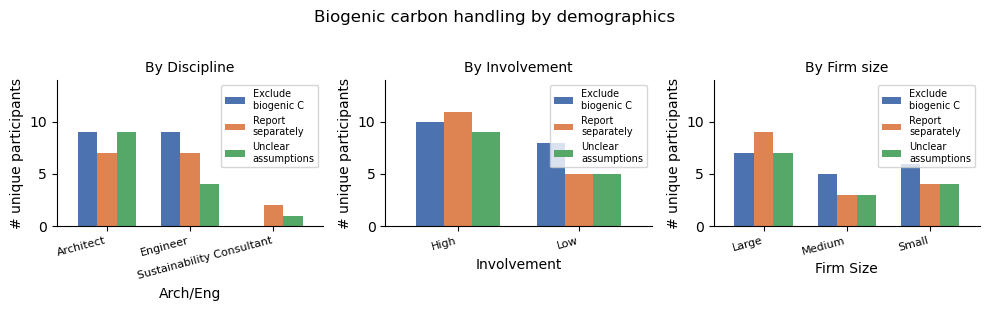

In [61]:
# Biogenic carbon claims by demographics
# 40/46 participants touched on biogenic carbon. Three meaningful demographic
# splits emerge: (1) no sustainability consultant excludes biogenic C;
# (2) architects cite unclear assumptions at twice the rate of engineers;
# (3) low-involvement and small-firm practitioners more often simply exclude it.

bio_claims = {
    'Exclude\nbiogenic C':   df_merged['TAG2'] == 'BIOGENIC CARBON: For biogenic carbon in my LCAs, I (exclude it)',
    'Report\nseparately':    df_merged['TAG2'] == 'BIOGENIC CARBON: For biogenic carbon in my LCAs, I (report it separately)',
    'Unclear\nassumptions':  df_merged['TAG2'] == 'BIOGENIC CARBON: The underlying assumptions are unclear',
}

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
demo_pairs = [
    ('Arch/Eng',    'Discipline'),
    ('Involvement', 'Involvement'),
    ('Firm Size',   'Firm size'),
]

for ax, (demo_col, demo_label) in zip(axes, demo_pairs):
    claim_df = pd.DataFrame({
        label: participant_counts(df_merged[mask], demo_col)['n']
        for label, mask in bio_claims.items()
    })
    claim_df.plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452', '#55A868'], width=0.7)
    ax.set_title(f'By {demo_label}', fontsize=10)
    ax.set_ylabel('# unique participants')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right', fontsize=8)
    ax.set_ylim(0, 14)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=7, loc='upper right')

fig.suptitle('Biogenic carbon handling by demographics', y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_Takeaway3_BiogenicCarbon.png', bbox_inches='tight')

# Key proportions for reference
print("Exclude biogenic C — by discipline:  Arch 9/20 (45%), Eng 9/20 (45%), Sust. Consult. 0/6 (0%)")
print("Unclear assumptions — by discipline: Arch 9/20 (45%), Eng 4/20 (20%), Sust. Consult. 1/6 (17%)")
print("Exclude biogenic C — by involvement: High 10/31 (32%), Low 8/15 (53%)")
print("Exclude biogenic C — by firm size:   Large 7/23 (30%), Medium 5/14 (36%), Small 6/9 (67%)")

## Takeaway 4: Advanced LCA methods are compelling but qualified

Interest is universal (all 46 participants). Prior awareness is very low — only 2/46 had heard of PLCA (both sustainability consultants) and 8/46 had heard of DLCA. Sustainability consultants are proportionally more aware. Barriers (learning curve, complexity) are consistent across all groups. Principals/CEOs cited specific barriers less often, suggesting project-level practitioners are more attuned to operational friction. Low-involvement practitioners more often tied advanced LCA adoption to client demand.

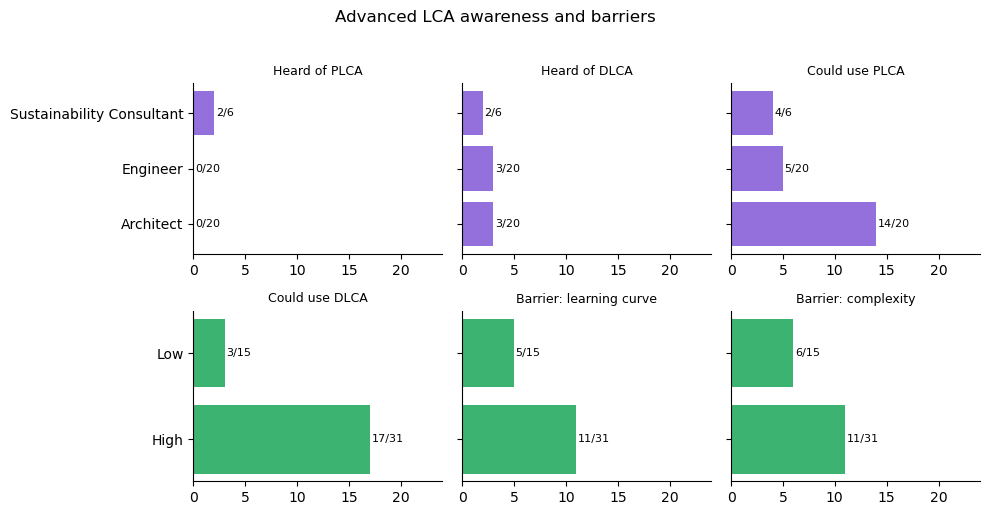

In [46]:
# Advanced LCA awareness and barriers by discipline and involvement
adv_tags = {
    'Heard of PLCA':    df_merged['TAG2'] == 'PLCA: I have heard of PLCA',
    'Heard of DLCA':    df_merged['TAG2'] == 'DLCA: I have heard of DLCA',
    'Could use PLCA':   df_merged['TAG2'] == 'PLCA: I could incorporate PLCA in my practice',
    'Could use DLCA':   df_merged['TAG2'] == 'DLCA: I could incorporate DLCA in my practice',
    'Barrier: learning curve': df_merged['TAG2'].str.contains('barrier.*learning curve', na=False, regex=True),
    'Barrier: complexity':     df_merged['TAG2'].str.contains('barrier.*complexity', na=False, regex=True),
}

fig, axes = plt.subplots(2, 3, figsize=(10, 5), sharey='row')
demo_keys = ['Arch/Eng', 'Involvement']
colors = ['mediumpurple', 'mediumseagreen']

for row_i, demo_col in enumerate(demo_keys):
    for col_i, (label, mask) in enumerate(list(adv_tags.items())[:3] if row_i == 0 else list(adv_tags.items())[3:]):
        ax = axes[row_i, col_i % 3]
        counts = participant_counts(df_merged[mask], demo_col)
        ax.barh(counts.index, counts['n'], color=colors[row_i])
        for i, (idx, row) in enumerate(counts.iterrows()):
            ax.text(row['n'] + 0.15, i, row['label'], va='center', fontsize=8)
        ax.set_xlim(0, 24)
        ax.set_title(label, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)

fig.suptitle("Advanced LCA awareness and barriers", y=1.02)
plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_Takeaway4_AdvancedLCA.png', bbox_inches='tight')

## Additional takeaways

**LCA timing is late — involvement level shifts it earlier.** High-involvement practitioners more often start at SD (18/31) while low-involvement practitioners more often start at CD (10/15), where major design decisions are already locked.

**LCA scope is discipline-determined.** Engineers predominantly use A1–A3 scope (10/20); sustainability consultants and high-involvement practitioners more often cover full A–C scope (5/6 and 15/31, respectively).

**Training burden falls on mid-level practitioners.** Difficulty training others was raised by 6/12 Project Designers and 5/16 Project Managers — the people expected to build organizational capacity — while on-the-job learning remains the dominant pathway (cited by 31 records vs. 16 for university).

**Low-involvement practitioners' barrier is organizational, not technical.** This group disproportionately cites "LCAs are undervalued" and difficulty prioritizing LCA over other work, suggesting that for practitioners on the margin, the obstacle is cultural rather than methodological.

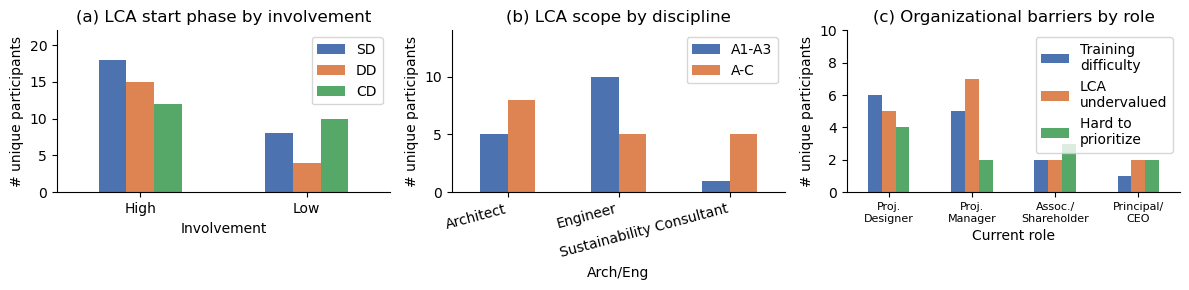

In [60]:
# Additional takeaways: timing, scope, training burden

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

# (a) LCA start phase by involvement
phase_tags = {'SD': 'during (SD', 'DD': 'during (DD', 'CD': 'during (CD'}
phase_counts = {}
for phase, substr in phase_tags.items():
    mask = df_merged['TAG2'].str.contains(substr, na=False, regex=False)
    phase_counts[phase] = participant_counts(df_merged[mask], 'Involvement')['n']
df_phase = pd.DataFrame(phase_counts)
df_phase.plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('(a) LCA start phase by involvement')
axes[0].set_ylabel('# unique participants')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_ylim(0, 22)
axes[0].spines[['top', 'right']].set_visible(False)

# (b) LCA scope (modules) by discipline
scope_tags = {'A1-A3': 'modules (A1-A3)', 'A-C': 'modules (A-C)'}
scope_counts = {}
for scope, substr in scope_tags.items():
    mask = df_merged['TAG2'].str.contains(substr, na=False, regex=False)
    scope_counts[scope] = participant_counts(df_merged[mask], 'Arch/Eng')['n']
df_scope = pd.DataFrame(scope_counts)
df_scope.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('(b) LCA scope by discipline')
axes[1].set_ylabel('# unique participants')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15, ha='right')
axes[1].set_ylim(0, 14)
axes[1].spines[['top', 'right']].set_visible(False)

# (c) Training burden and organizational undervaluation by role
burden_tags = {
    'Training\ndifficulty': df_merged['TAG2'] == 'PROBLEM: It is difficult to (train others to do LCA)',
    'LCA\nundervalued':     df_merged['TAG2'] == 'PROBLEM: A problem with LCAs is (LCAs are under valued)',
    'Hard to\nprioritize':  df_merged['TAG2'] == 'PROBLEM: It is difficult to (prioritize LCA over other work)',
}
role_order = ['Project Designer', 'Project Manager', 'Associate/Shareholder', 'Principal/CEO']
burden_df = pd.DataFrame(
    {label: participant_counts(df_merged[mask], 'Current role')['n'].reindex(role_order, fill_value=0)
     for label, mask in burden_tags.items()}
)
burden_df.plot(kind='bar', ax=axes[2], color=['#4C72B0', '#DD8452', '#55A868'])
axes[2].set_title('(c) Organizational barriers by role')
axes[2].set_ylabel('# unique participants')
axes[2].set_xticklabels(['Proj.\nDesigner', 'Proj.\nManager', 'Assoc./\nShareholder', 'Principal/\nCEO'],
                         rotation=0, fontsize=8)
axes[2].set_ylim(0, 10)
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('outputs/figures/DemoAnalysis_AdditionalTakeaways.png', bbox_inches='tight')